In [3]:
import data_bonelesions as kahler
import time
import torch
from torch.utils.data import DataLoader

start = time.time()

#dataset and data loader

construct_start = time.time()

#constructing the datasets
train_img_dir = "/wecare/home/daniel/Thesis/Dataset/448_patches/images/train"
train_mask_dir = "/wecare/home/daniel/Thesis/Dataset/448_patches/labels/train"
train_set = kahler.KahlerDataset(train_img_dir, train_mask_dir)

val_img_dir = "/wecare/home/daniel/Thesis/Dataset/448_patches/images/validation"
val_mask_dir = "/wecare/home/daniel/Thesis/Dataset/448_patches/labels/validation"
val_set = kahler.KahlerDataset(val_img_dir, val_mask_dir)

test_img_dir = "/wecare/home/daniel/Thesis/Dataset/448_patches/images/test"
test_mask_dir = "/wecare/home/daniel/Thesis/Dataset/448_patches/labels/test"
test_set = kahler.KahlerDataset(test_img_dir, test_mask_dir)

#data loaders
batch_size = 24

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

#test
images, masks = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Mask batch shape:", masks.shape)

construct_end = time.time()
print(f"Construct runtime {construct_end - construct_start}")

Image batch shape: torch.Size([24, 1, 448, 448])
Mask batch shape: torch.Size([24, 1, 448, 448])
Construct runtime 0.24736309051513672


SwinTransformerSys expand initial----depths:[2, 2, 2, 2];depths_decoder:[1, 2, 2, 2];drop_path_rate:0.1;num_classes:1
---final upsample expand_first---
Best epoch: 0
Epoch [1/150]  Train Loss: 0.6385  Val Loss: 0.6056  Val Dice: 0.0000  Val IoU: 0.0000   Runtime: 92.08225154876709
Epoch [2/150]  Train Loss: 0.6093  Val Loss: 0.6055  Val Dice: 0.0000  Val IoU: 0.0000   Runtime: 69.53123116493225
Epoch [3/150]  Train Loss: 0.6088  Val Loss: 0.6049  Val Dice: 0.0000  Val IoU: 0.0000   Runtime: 70.22980952262878
Epoch [4/150]  Train Loss: 0.6071  Val Loss: 0.6033  Val Dice: 0.0000  Val IoU: 0.0000   Runtime: 70.31872391700745
Epoch [5/150]  Train Loss: 0.6032  Val Loss: 0.6000  Val Dice: 0.0000  Val IoU: 0.0000   Runtime: 70.37041425704956
Best epoch: 5
Epoch [6/150]  Train Loss: 0.5889  Val Loss: 0.5974  Val Dice: 0.0318  Val IoU: 0.0166   Runtime: 70.7400381565094
Epoch [7/150]  Train Loss: 0.5880  Val Loss: 0.6026  Val Dice: 0.0000  Val IoU: 0.0000   Runtime: 70.42659258842468
Best epoc

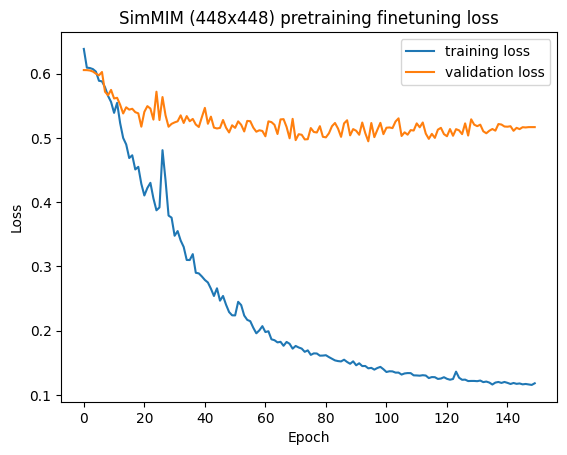

Test runtime 8.619939804077148
Mean dice coefficient on test set: 0.1121
Mean jaccard coefficient on test set: 0.0782
Mean loss on test set: 0.5013

Runtime: 10621.0371363163


In [ ]:
#training and validation loop

import torch
import torch.nn as nn
import torch.optim as optim
import models
import utils
from matplotlib import pyplot as plt
#import numpy as np
#import os

custom_image_size = 448

device = torch.device("cuda")
#model = models.SwinUnetFinetune(img_size=custom_image_size)
model = models.SwinUnetFinetune448()
#model = models.SwinUnetFinetuneImagenet()
#model = models.SwinUnetNewSize(custom_image_size)
model.to(device)
model.load_state_dict(torch.load("/wecare/home/daniel/Thesis/models/pretrain_simmim_448.pth", weights_only=True, map_location=device), strict=False)

base_lr = 0.01
criterion = utils.ComboLoss(alpha=0.6)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=0.0001)
num_epochs = 150
early_stopping = utils.EarlyStopping(patience=30, delta=0.001)

iterations_per_epoch = len(train_loader)
num_steps = num_epochs * iterations_per_epoch
step_num = 0

loss_save_path = "/wecare/home/daniel/Thesis/losses/finetune_lesions_loss2.png"
plot_title = "No pretraining finetuning loss"
final_model_save_path = "/wecare/home/daniel/Thesis/models/finetune_lesions_final2.pth"
best_model_save_path = "/wecare/home/daniel/Thesis/models/finetune_lesions_best2.pth"



start_train = time.time()

model.to(device)

train_loss_list = []
val_loss_list = []

best_val_dice = 0

#training loop
for epoch in range(num_epochs):

    epoch_start = time.time()

    #training
    train_loss = 0.0
    model.train()

    for idx, (images, masks) in enumerate(train_loader):

        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        lr_ = base_lr * (1.0 - (step_num / num_steps)) ** 0.9
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr_
        step_num += 1

        #balance the loss per batch size
        train_loss += loss.item() * images.size(0)
    

    train_loss /= len(train_loader.dataset)

    train_loss_list.append(train_loss)

    #validation
    val_loss = 0.0
    val_dice = 0.0
    val_iou = 0.0
    model.eval()
    
    with torch.no_grad():

        for images, masks in val_loader:

            images, masks = images.to(device), masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)
            dice, _ = utils.dice_coeff(outputs, masks)
            iou, _ = utils.jaccard_coeff(outputs, masks) 
            
            #balance the loss per batch size
            val_loss += loss.item() * images.size(0)
            val_dice += dice * images.size(0)
            val_iou += iou * images.size(0)
    
    val_loss /= len(val_loader.dataset)
    val_dice /= len(val_loader.dataset)
    val_iou /= len(val_loader.dataset)

    val_loss_list.append(val_loss)

    #early_stopping.check(val_loss)
    #if early_stopping.stop_training:
        #break
    
    #save the best model
    if best_val_dice < val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), best_model_save_path)
        print(f'Best epoch: {epoch}')

    epoch_end = time.time()

    print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}  Val Dice: {val_dice:.4f}  Val IoU: {val_iou:.4f}   Runtime: {epoch_end - epoch_start}")


end_train = time.time()

print(f"Train runtime: {end_train - start_train}")

#plot training and validation loss
plt.figure()
plt.plot(train_loss_list, label='training loss')
plt.plot(val_loss_list,label='validation loss')
plt.title(plot_title)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig(loss_save_path)
print(loss_save_path)
plt.show()


#testing loop
start_test = time.time()

test_dice = 0.0
test_iou = 0.0
test_loss = 0.0
model.eval()

with torch.no_grad():

    for images, masks in test_loader:

        images, masks = images.to(device), masks.to(device)

        outputs = model(images)
        dice, _ = utils.dice_coeff(outputs, masks)
        iou, _ = utils.jaccard_coeff(outputs, masks)
        loss = criterion(outputs, masks)
        
        #balance the loss per batch size
        test_dice += dice * images.size(0)
        test_iou += iou * images.size(0)
        test_loss += loss.item() * images.size(0)
    
test_dice /= len(test_loader.dataset)
test_iou /= len(test_loader.dataset)     
test_loss /= len(test_loader.dataset)

end_test = time.time()

print(f"Test runtime {end_test - start_test}")
print(f"Mean dice coefficient on test set: {test_dice:.4f}")
print(f"Mean jaccard coefficient on test set: {test_iou:.4f}")
print(f"Mean loss on test set: {test_loss:.4f}")


print()

torch.save(model.state_dict(), final_model_save_path)

end = time.time()
print(f"Runtime: {end - start}")